# BERT Embedding + KMeans / BERTopic Comment Topic Discovery

This notebook uses `data/filtered_comments.csv` as input and applies semantic embeddings to hotel review topic discovery:

1. BERT embedding + KMeans clustering
2. BERT embedding + BERTopic topic modeling

The existing `categories` column is removed before unsupervised modeling.

## 0. 环境依赖

In [1]:
import os

os.environ["http_proxy"] = ""
os.environ["https_proxy"] = ""
os.environ["all_proxy"] = ""

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances

plt.rcParams["axes.unicode_minus"] = False

## 1. Parameters

In [ ]:
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "filtered_comments.csv"

KMEANS_OUTPUT_DIR = Path("bert_kmeans_result")
BERTOPIC_OUTPUT_DIR = Path("bert_bertopic_result")
KMEANS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BERTOPIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


MODEL_NAME = "BAAI/bge-small-zh-v1.5"

EMBEDDING_PATH = KMEANS_OUTPUT_DIR / "comment_embeddings_bge_small_zh_v1_5.npy"
EMBEDDING_META_PATH = KMEANS_OUTPUT_DIR / "comment_embeddings_meta.json"

KMEANS_K_RANGE = range(2, 16)
KMEANS_N_CLUSTERS = 7
RANDOM_STATE = 42
BATCH_SIZE = 32

## 2. Read Filtered Comments

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Input data file not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
source_path = DATA_PATH

# Do not use existing category labels as features for unsupervised clustering.
df = df.drop(columns=["categories"], errors="ignore")

# Keep compatibility with the old notebook column names.
df = df.rename(columns={
    "comment_len": "comment_length",
    "log_comment_len": "log_comment_length",
})

if "_id" in df.columns:
    df = df.set_index("_id")

df["comment"] = df["comment"].fillna("").astype(str)
df = df[df["comment"].str.strip().ne("")].copy()

print(f"Data source: {source_path}")
print(f"Comment count: {len(df)}")
display(df.head())

Data source: data/filtered_comments.csv
Comment count: 2171


,comment,images,score,publish_date,room_type,fuzzy_room_type,travel_type,comment_length,log_comment_length,useful_count,log_useful_count,review_count,log_review_count,quality_score
_id,,,,,,,,,,,,,,
68027895e3c98b0941765706,房间非常好 装修很厚重奢华 一开始看评论 看酒店自己po的照片 感觉跟快捷酒店一样 有些害怕...,"[ ""https://dimg04.c-ctrip.com/images/0230y1200...",5.0,2025-04-05,红棉大床套房,套房,家庭亲子,320,5.771441,0,0.000000,7,2.079442,9
68027895e3c98b0941765707,花园酒店广州的老牌五星，一直期望的入住。房间我入住时要求前台帮我升级了新装修的房间，粤韵。其...,"[ ""https://dimg04.c-ctrip.com/images/023461200...",4.2,2025-04-07,红棉大床套房,套房,独自旅行,223,5.411646,0,0.000000,28,3.367296,8
68027895e3c98b0941765708,一进酒店就感觉来到了桃花源，迎宾人员都很热情，彬彬有礼，房间也非常不错，床品都很舒服，洗嗽用...,"[ ""https://dimg04.c-ctrip.com/images/023011200...",5.0,2025-04-15,花园双床房,双床房,商务出差,124,4.828314,0,0.000000,11,2.484907,8
68027895e3c98b0941765709,总体来说很好。早餐有两个地方可以用，最上层的旋转餐厅用早餐感觉还是非常不错的。另外酒店的后花...,"[ ""https://dimg04.c-ctrip.com/images/0231r1200...",5.0,2025-04-15,花园大床房,大床房,情侣出游,99,4.605170,1,0.693147,18,2.944439,9
68027895e3c98b094176570a,多年没来广州，临时起意过来住花园酒店，环境舒适，没有想象中的老式，全员服务在线，礼貌周到，给...,"[ ""https://dimg04.c-ctrip.com/images/0231o1200...",5.0,2025-04-06,花园双床房,双床房,家庭亲子,165,5.111988,0,0.000000,13,2.639057,9


## 3. 文本轻量清洗

BERT 类模型不需要像 TF-IDF 那样分词，但可以去掉 URL 和过多空白，减少噪声。

In [4]:
def clean_for_embedding(text):
    text = str(text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text_for_embedding"] = df["comment"].map(clean_for_embedding)
texts = df["text_for_embedding"].tolist()

print(texts[0][:500])

房间非常好 装修很厚重奢华 一开始看评论 看酒店自己po的照片 感觉跟快捷酒店一样 有些害怕 但来了之后 真的很惊喜 装修很厚重 很奢华 跟一些老牌的日系酒店 （帝国酒店）之类的感觉 没想到在广州也有这样开业时间很长但仍然配套跟得上的酒店。。 服务很好！ 门童拿行李迎宾开门 比一些国际连锁的五星要好多了。 退房时候liren还帮忙直接登记了退房 不用排队了。什么时候北京的酒店服务也能跟上广州呢。。。 另外吃的真的很好 晚上去楼顶旋转自助吃 螃蟹腿鲍鱼进口生蚝 吃撑了 还有最爱吃的金蒜牛肉 做的真的很好吃 比北京第六季那种什么海鲜都拿来涮的自助强好多 酒店里还有花园 大锦鲤吃的真的好 又大又肥 总体来说 物超所值 下次还来


## 4. 生成或读取 BERT Embedding

第一次运行会下载模型并生成 embedding，之后会从 `bert_result` 目录读取缓存，避免重复计算。

In [5]:
def embedding_cache_is_valid(meta_path, expected_model, expected_count):
    if not meta_path.exists():
        return False
    try:
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
    except Exception:
        return False
    return meta.get("model_name") == expected_model and meta.get("text_count") == expected_count

if EMBEDDING_PATH.exists() and embedding_cache_is_valid(EMBEDDING_META_PATH, MODEL_NAME, len(texts)):
    embeddings = np.load(EMBEDDING_PATH)
    print(f"已读取 embedding 缓存：{EMBEDDING_PATH}")
else:
    model = SentenceTransformer(MODEL_NAME)
    embeddings = model.encode(
        texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    embeddings = np.asarray(embeddings, dtype=np.float32)
    np.save(EMBEDDING_PATH, embeddings)
    EMBEDDING_META_PATH.write_text(
        json.dumps({"model_name": MODEL_NAME, "text_count": len(texts)}, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"已保存 embedding：{EMBEDDING_PATH}")

print(f"Embedding shape: {embeddings.shape}")

/root/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/68 [00:00<?, ?it/s]

已保存 embedding：bert_kmeans_result/comment_embeddings_bge_small_zh_v1_5.npy
Embedding shape: (2171, 512)


# A. BERT Embedding + KMeans

## A1. 选择 KMeans 聚类数

这里使用 inertia 和 silhouette score 辅助选择 `k`

,k,inertia,silhouette
0,2,728.132324,0.102859
1,3,708.131897,0.081974
2,4,694.023132,0.083432
3,5,682.093445,0.084515
4,6,672.883789,0.081295
5,7,664.522522,0.061181
6,8,656.586670,0.062929
7,9,651.621460,0.063389
8,10,647.254150,0.057370
9,11,643.778137,0.063533


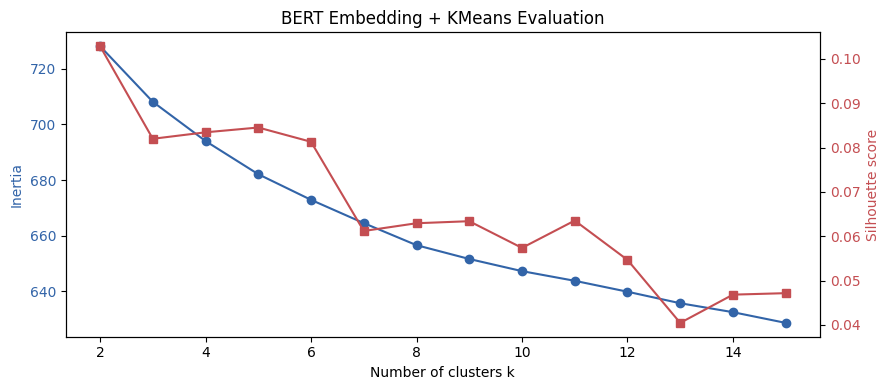

In [6]:
kmeans_metrics = []

for k in KMEANS_K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20, max_iter=300)
    labels = km.fit_predict(embeddings)
    sil = silhouette_score(embeddings, labels, metric="cosine")
    kmeans_metrics.append({"k": k, "inertia": km.inertia_, "silhouette": sil})

df_kmeans_metrics = pd.DataFrame(kmeans_metrics)
display(df_kmeans_metrics)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(df_kmeans_metrics["k"], df_kmeans_metrics["inertia"], marker="o", color="#3264a8")
ax1.set_xlabel("Number of clusters k")
ax1.set_ylabel("Inertia", color="#3264a8")
ax1.tick_params(axis="y", labelcolor="#3264a8")

ax2 = ax1.twinx()
ax2.plot(df_kmeans_metrics["k"], df_kmeans_metrics["silhouette"], marker="s", color="#c44e52")
ax2.set_ylabel("Silhouette score", color="#c44e52")
ax2.tick_params(axis="y", labelcolor="#c44e52")

plt.title("BERT Embedding + KMeans Evaluation")
plt.tight_layout()
plt.show()

## A2. 训练最终 KMeans 模型

In [7]:
KMEANS_N_CLUSTERS = 5
kmeans = KMeans(n_clusters=KMEANS_N_CLUSTERS, random_state=RANDOM_STATE, n_init=20, max_iter=300)
df_kmeans = df.copy()
df_kmeans["bert_kmeans_cluster"] = kmeans.fit_predict(embeddings)

cluster_counts = (
    df_kmeans["bert_kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)

display(cluster_counts)
print(f"Final silhouette: {silhouette_score(embeddings, df_kmeans['bert_kmeans_cluster'], metric='cosine'):.4f}")

,cluster,count
0,0,350
1,1,526
2,2,399
3,3,588
4,4,308


Final silhouette: 0.0845


## A3. 提取 KMeans 代表评论

对于 embedding 聚类，不能像 TF-IDF 一样直接从聚类中心读取关键词。因此这里先输出每个簇距离中心最近的代表评论，后续可人工命名。

In [8]:
kmeans_distances = cosine_distances(embeddings, kmeans.cluster_centers_)
kmeans_representative_rows = []

for cluster_id in range(KMEANS_N_CLUSTERS):
    positions = np.where(df_kmeans["bert_kmeans_cluster"].to_numpy() == cluster_id)[0]
    nearest_positions = positions[np.argsort(kmeans_distances[positions, cluster_id])[:8]]
    for rank, pos in enumerate(nearest_positions, start=1):
        row = df_kmeans.iloc[pos]
        kmeans_representative_rows.append({
            "cluster": cluster_id,
            "rank": rank,
            "_id": row.name,
            "score": row.get("score", np.nan),
            "quality_score": row.get("quality_score", np.nan),
            "room_type": row.get("room_type", ""),
            "comment": row["comment"][:500],
        })

kmeans_representatives = pd.DataFrame(kmeans_representative_rows)
display(kmeans_representatives)

,cluster,rank,_id,score,quality_score,room_type,comment
0,0,1,68027d41e3c98b0941765b0b,5.0,9,花园大床房,酒店有文化沉淀，有独到设计，有中西交融，有优质服务，将花园特色融入每个角落，漂亮大气。值得一...
1,0,2,680278c1e3c98b094176572e,5.0,8,花园双床房,这次的花园酒店很是满意??酒店硬件无可挑剔，大堂，客房都很有设计感，交通更是方便，出门就是地...
2,0,3,68027a4de3c98b0941765885,5.0,7,花园大床房,房间安排非常舒适，卫生整理及时。酒店后花园让人感到温暖、温馨??；早餐丰富、服务生态度绝对到...
3,0,4,68028542e3c98b0941766085,5.0,7,花园双床房,房间非常好，设施设备齐全，服务热情周到，酒店的餐饮也非常好。花园酒店有一个博物馆，介绍了酒店...
4,0,5,68027d95e3c98b0941765b49,5.0,5,花园双床房,名副其实的花园酒店，瀑布餐厅，庭院都很有特色哦\n\n卫生：干净\n服务：很好\n\n设施：很好
5,0,6,680279f2e3c98b0941765833,5.0,7,花园大床房,酒店高大上，房间干净整洁优雅，服务一流。花园设计漂亮心怡，有红色小桥，有大瀑布，还有不同种的...
6,0,7,68027f36e3c98b0941765cb0,5.0,6,花园双床房,花园景色优美，服务优良，不愧是老牌五星级酒店～ 很多外国人，也是一景～ 酒店的性价比不错，还...
7,0,8,68027d03e3c98b0941765ad6,5.0,8,花园双床房,房间挺好的，环境不错，服务也好，酒店大气，有花园，花园里有许多锦鲤鱼，还有人造瀑布，循环水溪...
8,1,1,68027a4de3c98b0941765882,5.0,8,花园大床房,服务非常好，酒店环境也很好，尤其是自带一个花园，有曲径通幽的感觉，瀑布花园、30层的旋转餐厅...
9,1,2,6802792ae3c98b0941765789,5.0,7,花园双床房,酒店服务很好！餐厅特别棒！早餐非常好！花园和博物馆也可以看看。门口就可以直接坐出租车，非常便...


## A4. 保存 KMeans 结果

In [9]:
KMEANS_CLUSTER_PATH = KMEANS_OUTPUT_DIR / "guangzhou_garden_hotel_bert_kmeans_clusters.csv"
KMEANS_METRICS_PATH = KMEANS_OUTPUT_DIR / "guangzhou_garden_hotel_bert_kmeans_metrics.csv"
KMEANS_REPRESENTATIVES_PATH = KMEANS_OUTPUT_DIR / "guangzhou_garden_hotel_bert_kmeans_representatives.csv"

df_kmeans.to_csv(KMEANS_CLUSTER_PATH)
df_kmeans_metrics.to_csv(KMEANS_METRICS_PATH, index=False)
kmeans_representatives.to_csv(KMEANS_REPRESENTATIVES_PATH, index=False)

print(f"Saved: {KMEANS_CLUSTER_PATH}")
print(f"Saved: {KMEANS_METRICS_PATH}")
print(f"Saved: {KMEANS_REPRESENTATIVES_PATH}")

Saved: bert_kmeans_result/guangzhou_garden_hotel_bert_kmeans_clusters.csv
Saved: bert_kmeans_result/guangzhou_garden_hotel_bert_kmeans_metrics.csv
Saved: bert_kmeans_result/guangzhou_garden_hotel_bert_kmeans_representatives.csv


# B. BERT Embedding + BERTopic

## B1. 训练 BERTopic 模型

BERTopic 通常使用 embedding + UMAP + HDBSCAN + c-TF-IDF。与 KMeans 不同，它一般不需要预先指定主题数，并且可能将部分评论标记为 `-1`，表示离群文本。

In [10]:
try:
    import jieba
    from bertopic import BERTopic
    from hdbscan import HDBSCAN
    from sklearn.feature_extraction.text import CountVectorizer
    from umap import UMAP
except ImportError as exc:
    raise ImportError(
        "缺少 BERTopic 相关依赖，请先安装：pip install bertopic umap-learn hdbscan jieba"
    ) from exc

STOPWORDS = set("""
的 了 和 是 就 都 而 及 与 着 或 一个 一些 这个 那个 这里 那里 我们 你们 他们
很 非常 比较 真的 还是 感觉 觉得 但是 不过 因为 所以 如果 以及 还有 没有
酒店 房间 入住 评论 客人 客服 携程 广州 花园 可以 不是 一下 一直 这家
也 都 会 有 在 对 中 上 下 里 到 去 来 让 给 被 从 把 还 又 再 更 最
""".split())

def jieba_tokenizer_for_topic(text):
    words = jieba.lcut(str(text))
    tokens = []
    for word in words:
        word = word.strip().lower()
        if len(word) <= 1:
            continue
        if word in STOPWORDS:
            continue
        if word.isdigit():
            continue
        tokens.append(word)
    return tokens

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

vectorizer_model = CountVectorizer(
    tokenizer=jieba_tokenizer_for_topic,
    token_pattern=None,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
)

topic_model = BERTopic(
    language="multilingual",
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
)

topics, probabilities = topic_model.fit_transform(texts, embeddings=embeddings)

df_bertopic = df.copy()
df_bertopic["bertopic_topic"] = topics

display(topic_model.get_topic_info().head(30))

2026-06-08 18:07:52,038 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
/root/miniconda3/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
2026-06-08 18:08:13,106 - BERTopic - Dimensionality - Completed ✓
2026-06-08 18:08:13,109 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-08 18:08:13,234 - BERTopic - Cluster - Completed ✓
2026-06-08 18:08:13,238 - BERTopic - Representation - Fine-tuning topics using representation models.
Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
Loading model cost 0.797 seconds.
Prefix dict has been built successfully.
2026-06-08 18:08:15,277 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,678,-1_博物馆_瀑布_有点_舒服,"[博物馆, 瀑布, 有点, 舒服, 排队, 客房, 免费, 花园酒店, 办理, 套房]",[国庆去旅行 房间设施:60+平方，一房一厅一卫，麻雀虽小五脏俱全，两个1.35的床，三口之...
1,0,706,0_花园酒店_瀑布_博物馆_酒廊,"[花园酒店, 瀑布, 博物馆, 酒廊, 荔湾, 行政 酒廊, 办理, 老牌, 舒适, 五星]",[超预期的好评，也感叹40年用心经营的本土酒店品牌也可以很棒。因为过年带父母和孩子一起到广州...
2,1,145,1_瀑布_花园酒店_瀑布 餐厅_博物馆,"[瀑布, 花园酒店, 瀑布 餐厅, 博物馆, 后花园, 泳池, 超级, 整洁, 充电, 套房]",[自带瀑布花园的宝藏酒店，大堂布满鲜花，巨幅红楼梦贴金壁画金碧辉煌，气派华贵；旋转楼梯相当出...
3,2,68,2_卫生 干净_舒适_有点_卫生间,"[卫生 干净, 舒适, 有点, 卫生间, 房型, 交通, 干净 环境, 服务 服务, 整洁,...",[设施：先说床品，非常非常赞，保障了优质的睡眠。房间设施略老旧，出现短路跳闸的故障。 卫生：...
4,3,59,3_浴缸_房卡_然后_晚上,"[浴缸, 房卡, 然后, 晚上, 办理, 等待, 信息, 再次, 沟通, 打电话]",[作为一家老牌白金五星级酒店，酒店环境依然是酒店门面。 设施：刚到房间就遇到打不开门，又要跑...
5,4,58,4_viria_kamille_前台 viria_舒适,"[viria, kamille, 前台 viria, 舒适, 帮忙, 舒服, winnie,...",[每位酒店的工作人员都非常的热情，特别是rain让人感觉很舒服，环境也很赞，最主要的是干净卫...
6,5,51,5_春节_过年_期间_活动,"[春节, 过年, 期间, 活动, 春节 期间, 气氛, 氛围, 舞狮, 过年 期间, 热闹]",[一如既往的好，尤其是春节期间，特别热闹又有年味。服务比多家五星级酒店更好，出街期间除了大堂...
7,6,45,6_地铁站_出行 方便_出来_地铁,"[地铁站, 出行 方便, 出来, 地铁, 地理位置, 出来 就是, 交通, 地铁口, 出门,...",[环境不错，服务态度也好，带小朋友出来旅游的，出门就是地铁口，出行方便周围也有很多好吃的。就...
8,7,44,7_丰富_品种_餐厅 早餐_舒服,"[丰富, 品种, 餐厅 早餐, 舒服, 早餐 品种, 味道, 旋转, 瀑布, 服务 早餐, ...",[大堂、餐厅、花园等公共区域环境很好。房间有点儿小，有咖啡机很不错，茶难喝，打扫的非常及时。...
9,8,43,8_服务 贴心_特别 服务_外国_老牌,"[服务 贴心, 特别 服务, 外国, 老牌, 虽然, 很漂亮, 一次 体验, 满意 一次, ...","[酒店环境舒适，令人心情愉悦。管理注重服务质量，员工服务贴心周到。, 体验特别好，服务很细心..."


## B2. 查看 BERTopic 主题词与代表评论

In [11]:
topic_info = topic_model.get_topic_info()

topic_keyword_rows = []
for topic_id in topic_info["Topic"].tolist():
    if topic_id == -1:
        keywords = []
    else:
        keywords = [word for word, weight in topic_model.get_topic(topic_id)[:15]]
    topic_keyword_rows.append({
        "topic": topic_id,
        "count": int(topic_info.loc[topic_info["Topic"] == topic_id, "Count"].iloc[0]),
        "keywords": "、".join(keywords),
    })

bertopic_keywords = pd.DataFrame(topic_keyword_rows)
display(bertopic_keywords.head(30))

bertopic_representative_rows = []
representative_docs = topic_model.get_representative_docs()

for topic_id, docs in representative_docs.items():
    for rank, doc in enumerate(docs[:8], start=1):
        matches = df_bertopic.index[df_bertopic["text_for_embedding"] == doc].tolist()
        doc_id = matches[0] if matches else ""
        bertopic_representative_rows.append({
            "topic": topic_id,
            "rank": rank,
            "_id": doc_id,
            "comment": doc[:500],
        })

bertopic_representatives = pd.DataFrame(bertopic_representative_rows)
display(bertopic_representatives.head(80))

,topic,count,keywords
0,-1,678,
1,0,706,花园酒店、瀑布、博物馆、酒廊、荔湾、行政 酒廊、办理、老牌、舒适、五星
2,1,145,瀑布、花园酒店、瀑布 餐厅、博物馆、后花园、泳池、超级、整洁、充电、套房
3,2,68,卫生 干净、舒适、有点、卫生间、房型、交通、干净 环境、服务 服务、整洁、唯一
4,3,59,浴缸、房卡、然后、晚上、办理、等待、信息、再次、沟通、打电话
5,4,58,viria、kamille、前台 viria、舒适、帮忙、舒服、winnie、价格、小姐姐 ...
6,5,51,春节、过年、期间、活动、春节 期间、气氛、氛围、舞狮、过年 期间、热闹
7,6,45,地铁站、出行 方便、出来、地铁、地理位置、出来 就是、交通、地铁口、出门、附近
8,7,44,丰富、品种、餐厅 早餐、舒服、早餐 品种、味道、旋转、瀑布、服务 早餐、旋转 餐厅
9,8,43,服务 贴心、特别 服务、外国、老牌、虽然、很漂亮、一次 体验、满意 一次、不愧、周到


,topic,rank,_id,comment
0,-1,1,680279b5e3c98b0941765809,国庆去旅行 房间设施:60+平方，一房一厅一卫，麻雀虽小五脏俱全，两个1.35的床，三口之家...
1,-1,2,68027f20e3c98b0941765c9f,绝对超预期的感受。 首先一进门，就有白衣男生主动帮忙拿行李送至大堂。 接着粉衣女生开始为我们...
2,-1,3,68027a8be3c98b09417658bb,非常有年代和历史沉淀感的一家酒店，我呢，怀着对参观历史建筑一份期望入住此酒店。但却是我入住所...
3,0,1,680278d8e3c98b0941765744,超预期的好评，也感叹40年用心经营的本土酒店品牌也可以很棒。因为过年带父母和孩子一起到广州旅...
4,0,2,68028542e3c98b09417660d8,在广州居住很多年，17年离开后每年也一定会回来小住一段时间，期间住过很多酒店，包括久负盛名的...
5,0,3,68028542e3c98b0941766125,在广州居住很多年，17年离开后每年也一定会回来小住一段时间，期间住过很多酒店，包括久负盛名的...
6,1,1,68028542e3c98b094176616a,自带瀑布花园的宝藏酒店，大堂布满鲜花，巨幅红楼梦贴金壁画金碧辉煌，气派华贵；旋转楼梯相当出片...
7,1,2,68027c04e3c98b09417659fb,真是宝藏酒店啊，本身就是个度假地，很气派精致优雅老钱风，有历史有文化有品位，瀑布餐厅，岭南花...
8,1,3,680278c1e3c98b0941765736,不愧叫花园酒店，随处可见的花花，令人心旷神怡～外面看着很大气，一进去给人富丽堂皇的感觉，房间...
9,2,1,68027e88e3c98b0941765c1d,设施：先说床品，非常非常赞，保障了优质的睡眠。房间设施略老旧，出现短路跳闸的故障。 卫生：卫...


## B3. 保存 BERTopic 结果

In [12]:
BERTOPIC_CLUSTER_PATH = BERTOPIC_OUTPUT_DIR / "guangzhou_garden_hotel_bertopic_topics.csv"
BERTOPIC_INFO_PATH = BERTOPIC_OUTPUT_DIR / "guangzhou_garden_hotel_bertopic_topic_info.csv"
BERTOPIC_KEYWORDS_PATH = BERTOPIC_OUTPUT_DIR / "guangzhou_garden_hotel_bertopic_keywords.csv"
BERTOPIC_REPRESENTATIVES_PATH = BERTOPIC_OUTPUT_DIR / "guangzhou_garden_hotel_bertopic_representatives.csv"
BERTOPIC_MODEL_DIR = BERTOPIC_OUTPUT_DIR / "bertopic_model"

df_bertopic.to_csv(BERTOPIC_CLUSTER_PATH)
topic_info.to_csv(BERTOPIC_INFO_PATH, index=False)
bertopic_keywords.to_csv(BERTOPIC_KEYWORDS_PATH, index=False)
bertopic_representatives.to_csv(BERTOPIC_REPRESENTATIVES_PATH, index=False)

# Save the BERTopic model for reuse. Loading it later requires compatible package versions.
topic_model.save(str(BERTOPIC_MODEL_DIR), serialization="pickle")

print(f"Saved: {BERTOPIC_CLUSTER_PATH}")
print(f"Saved: {BERTOPIC_INFO_PATH}")
print(f"Saved: {BERTOPIC_KEYWORDS_PATH}")
print(f"Saved: {BERTOPIC_REPRESENTATIVES_PATH}")
print(f"Saved model: {BERTOPIC_MODEL_DIR}")

2026-06-08 18:11:44,514 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved: bert_bertopic_result/guangzhou_garden_hotel_bertopic_topics.csv
Saved: bert_bertopic_result/guangzhou_garden_hotel_bertopic_topic_info.csv
Saved: bert_bertopic_result/guangzhou_garden_hotel_bertopic_keywords.csv
Saved: bert_bertopic_result/guangzhou_garden_hotel_bertopic_representatives.csv
Saved model: bert_bertopic_result/bertopic_model
